## Intel Image Classification (CNN - Keras)

Trong notebook này, chúng ta sẽ xây dựng và triển khai một mô hình **Convolutional Neural Network (CNN)** bằng **Keras** để thực hiện bài toán phân loại ảnh trên bộ dữ liệu **Intel Image Classification**.

Các bước chính bao gồm:

- Import các thư viện cần thiết.
- Tải và khám phá bộ dữ liệu.
- Trực quan hóa và tiền xử lý ảnh.
- Xây dựng và huấn luyện một mô hình CNN cơ bản.
- Đánh giá hiệu suất của mô hình.
- Áp dụng mô hình học chuyển giao (Transfer Learning) với các mô hình đã được huấn luyện trước (pre-trained models) để cải thiện kết quả phân loại.


## Import Packages


In [1]:
import numpy as np
import os
from sklearn.metrics import confusion_matrix
import seaborn as sn; sn.set(font_scale=1.4)
from sklearn.utils import shuffle           
import matplotlib.pyplot as plt             
import cv2                                 
import tensorflow as tf                
from tqdm import tqdm

In [2]:
class_names = ['mountain', 'street', 'glacier', 'buildings', 'sea', 'forest']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

IMAGE_SIZE = (150, 150)

## Tải dữ liệu

Chúng ta cần xây dựng một hàm load_data để tải các ảnh và nhãn (labels) từ các thư mục chứa dữ liệu.


In [3]:
def load_data():
    """
        Load the data:
            - 14,034 images to train the network.
            - 3,000 images to evaluate how accurately the network learned to classify images.
    """
    
    datasets = ['/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train', '/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test']
    output = []
    
    # Iterate through training and test sets
    for dataset in datasets:
        
        images = []
        labels = []
        
        print("Loading {}".format(dataset))
        
        # Iterate through each folder corresponding to a category
        for folder in os.listdir(dataset):
            label = class_names_label[folder]
            
            # Iterate through each image in our folder
            for file in tqdm(os.listdir(os.path.join(dataset, folder))):
                
                # Get the path name of the image
                img_path = os.path.join(os.path.join(dataset, folder), file)
                
                # Open and resize the img
                image = cv2.imread(img_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
                image = cv2.resize(image, IMAGE_SIZE) 
                
                # Append the image and its corresponding label to the output
                images.append(image)
                labels.append(label)
                
        images = np.array(images, dtype = 'float32')
        labels = np.array(labels, dtype = 'int32')   
        
        output.append((images, labels))

    return output

In [4]:
(train_images, train_labels), (test_images, test_labels) = load_data()

Loading /kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train


100%|██████████| 2404/2404 [00:19<00:00, 122.21it/s]


Loading /kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test


100%|██████████| 553/553 [00:04<00:00, 126.19it/s]


In [5]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

## Khám phá bộ dữ liệu

Trước khi xây dựng mô hình, chúng ta sẽ tìm hiểu một số đặc điểm cơ bản của bộ dữ liệu thông qua các câu hỏi sau:

- Có bao nhiêu mẫu dữ liệu trong tập huấn luyện (training set) và tập kiểm tra (testing set)?
- Kích thước của mỗi ảnh là bao nhiêu?
- Tỷ lệ phân bố của từng lớp (category) trong bộ dữ liệu như thế nào?


In [6]:
n_train = train_labels.shape[0]
n_test = test_labels.shape[0]

print ("Number of training examples: {}".format(n_train))
print ("Number of testing examples: {}".format(n_test))
print ("Each image is of size: {}".format(IMAGE_SIZE))

Number of training examples: 14034
Number of testing examples: 3000
Each image is of size: (150, 150)


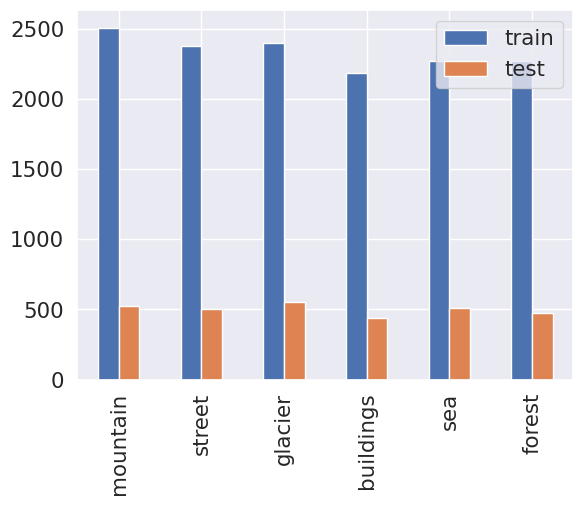

In [7]:
import pandas as pd

_, train_counts = np.unique(train_labels, return_counts=True)
_, test_counts = np.unique(test_labels, return_counts=True)
pd.DataFrame({'train': train_counts,
                    'test': test_counts}, 
             index=class_names
            ).plot.bar()
plt.show()

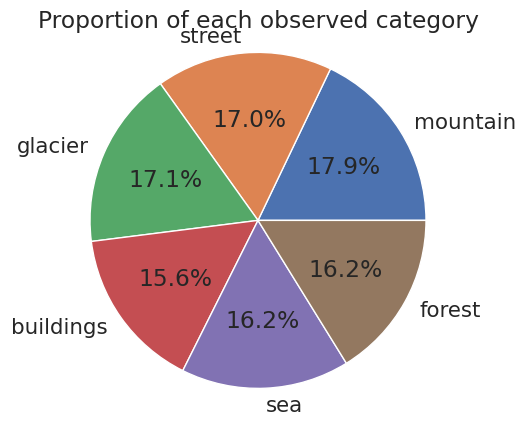

In [8]:
plt.pie(train_counts,
        explode=(0, 0, 0, 0, 0, 0) , 
        labels=class_names,
        autopct='%1.1f%%')
plt.axis('equal')
plt.title('Proportion of each observed category')
plt.show()

### Chuẩn hóa dữ liệu

Một bước tiền xử lý quan trọng là **chuẩn hóa dữ liệu (scaling)**. Việc đưa giá trị của các điểm ảnh về cùng một khoảng giá trị giúp quá trình huấn luyện ổn định hơn, tăng tốc độ hội tụ và cải thiện hiệu suất của mô hình.


In [9]:
train_images = train_images / 255.0 
test_images = test_images / 255.0

### Trực quan hóa dữ liệu

Chúng ta có thể hiển thị một hình ảnh ngẫu nhiên từ tập dữ liệu huấn luyện để quan sát và hiểu rõ hơn về dữ liệu đầu vào.


In [10]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """
    
    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{} : '.format(index) + class_names[labels[index]])
    plt.show()

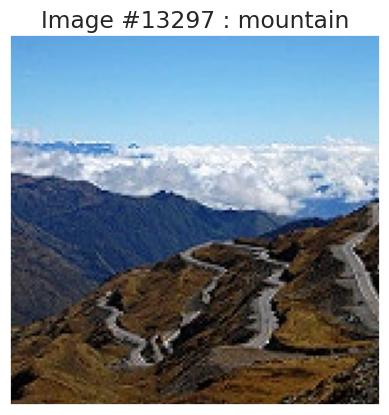

In [11]:
display_random_image(class_names, train_images, train_labels)

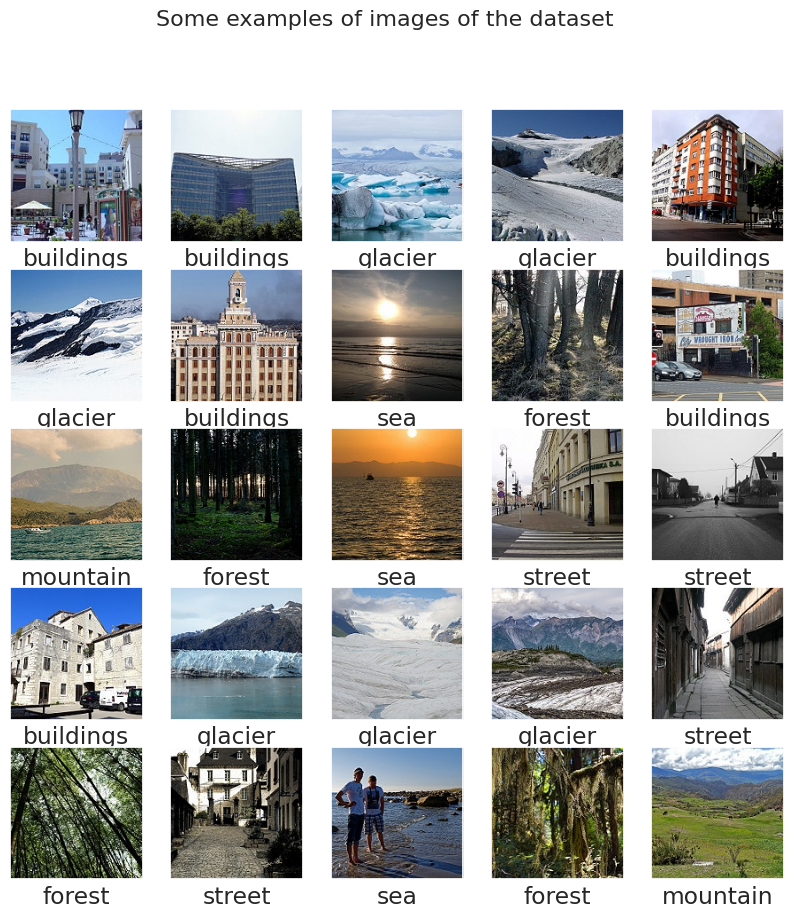

In [12]:
def display_examples(class_names, images, labels):
    """
        Display 25 images from the images array with its corresponding labels
    """
    
    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[labels[i]])
    plt.show()
    
display_examples(class_names, train_images, train_labels)

## Beginner: Xây dựng mô hình đơn giản

Các bước thực hiện:

1. **Xây dựng mô hình (Build the model)**  
   Thiết kế kiến trúc mạng CNN với các lớp cần thiết.

2. **Biên dịch mô hình (Compile the model)**  
   Cấu hình mô hình với hàm mất mát (loss function), bộ tối ưu (optimizer) và các chỉ số đánh giá (metrics).

3. **Huấn luyện mô hình (Train / Fit the model)**  
   Đưa dữ liệu huấn luyện vào mô hình để mô hình học các đặc trưng từ ảnh.

4. **Đánh giá mô hình trên tập kiểm tra (Evaluate the model)**  
   Kiểm tra khả năng phân loại của mô hình trên tập dữ liệu chưa được sử dụng trong quá trình huấn luyện.

5. **Phân tích lỗi của mô hình (Error analysis)**  
   Xem xét các dự đoán sai để hiểu điểm yếu và khả năng cải thiện mô hình.

Một mô hình CNN đơn giản có thể được xây dựng từ các lớp sau:

- **Conv2D (32 filters, kích thước 3×3):**  
  Trích xuất các đặc trưng (features) từ hình ảnh thông qua các bộ lọc tích chập.

- **MaxPooling2D:**  
  Giảm kích thước không gian của ảnh xuống một nửa, giúp giảm số lượng tham số và tăng khả năng tổng quát hóa.

- **Flatten:**  
  Chuyển đổi dữ liệu ảnh từ dạng mảng 2 chiều (2D array) với kích thước `150 × 150 × 3` thành một vector 1 chiều để đưa vào các lớp Dense.

- **ReLU (Rectified Linear Unit):**  
  Hàm kích hoạt nhận giá trị đầu vào `x` và trả về `max(x, 0)`, giúp mô hình học được các quan hệ phi tuyến.

- **Softmax:**  
  Gồm 6 neuron đầu ra, mỗi neuron biểu diễn xác suất để một ảnh thuộc về một trong 6 lớp của bộ dữ liệu.


In [13]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(150,150,3)),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(6, activation='softmax')
])

I0000 00:00:1783439434.198173      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783439434.204128      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Biên dịch mô hình (Compile the model)

Sau khi xây dựng kiến trúc mô hình, chúng ta cần biên dịch mô hình với một số tham số quan trọng:

- **Optimizer: Adam**  
  Thuật toán tối ưu **Adam** là sự kết hợp giữa **RMSProp** và **Momentum**, giúp cập nhật trọng số của mô hình hiệu quả hơn trong quá trình huấn luyện.
  - **Momentum:**  
    Sử dụng thông tin từ các gradient trước đó để thực hiện cập nhật trọng số ổn định hơn, giúp mô hình tránh dao động và hội tụ nhanh hơn.

  - **RMSProp (Root Mean Square Propagation):**  
    Tính toán trung bình có trọng số theo hàm mũ của bình phương các gradient trước đó, từ đó điều chỉnh tốc độ học (learning rate) phù hợp cho từng tham số.

- **Loss function: Sparse Categorical Crossentropy**  
  Được sử dụng cho bài toán phân loại nhiều lớp, trong đó mỗi ảnh chỉ thuộc về **một lớp duy nhất**. Hàm mất mát này đo sự khác biệt giữa nhãn thật và xác suất dự đoán của mô hình.


In [15]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [16]:
history = model.fit(train_images, train_labels, batch_size=128, epochs=20, validation_split = 0.2)

Epoch 1/20


2026-07-07 15:50:45.883550: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 15:50:46.035840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 3/88 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.2174 - loss: 4.7855

I0000 00:00:1783439449.461109     137 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/88 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.4073 - loss: 2.2712

2026-07-07 15:50:55.757068: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-07 15:50:55.905855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


88/88 ━━━━━━━━━━━━━━━━━━━━ 20s 151ms/step - accuracy: 0.5264 - loss: 1.4245 - val_accuracy: 0.6334 - val_loss: 0.9409
Epoch 2/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.6894 - loss: 0.8291 - val_accuracy: 0.7146 - val_loss: 0.8057
Epoch 3/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.7607 - loss: 0.6524 - val_accuracy: 0.7549 - val_loss: 0.6799
Epoch 4/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.7987 - loss: 0.5615 - val_accuracy: 0.7681 - val_loss: 0.6554
Epoch 5/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8399 - loss: 0.4568 - val_accuracy: 0.7659 - val_loss: 0.6502
Epoch 6/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.8815 - loss: 0.3534 - val_accuracy: 0.7709 - val_loss: 0.6591
Epoch 7/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 64ms/step - accuracy: 0.9054 - loss: 0.2844 - val_accuracy: 0.7724 - val_loss: 0.6867
Epoch 8/20
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9352 - loss: 0.2072 - val_accuracy: 0.7585 - val_loss: 

In [17]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [18]:
def plot_accuracy_loss(history):
    """
        Plot the accuracy and the loss during the training of the nn.
    """
    fig = plt.figure(figsize=(10,5))

    # Plot accuracy
    plt.subplot(221)
    plt.plot(history.history['accuracy'], 'bo--', label="acc")
    plt.plot(history.history['val_accuracy'], 'ro--', label="val_acc")
    plt.title("train_acc vs val_acc")
    plt.ylabel("accuracy")
    plt.xlabel("epochs")
    plt.legend()

    # Plot loss function
    plt.subplot(222)
    plt.plot(history.history['loss'], 'bo--', label="loss")
    plt.plot(history.history['val_loss'], 'ro--', label="val_loss")
    plt.title("train_loss vs val_loss")
    plt.ylabel("loss")
    plt.xlabel("epochs")

    plt.legend()
    plt.show()

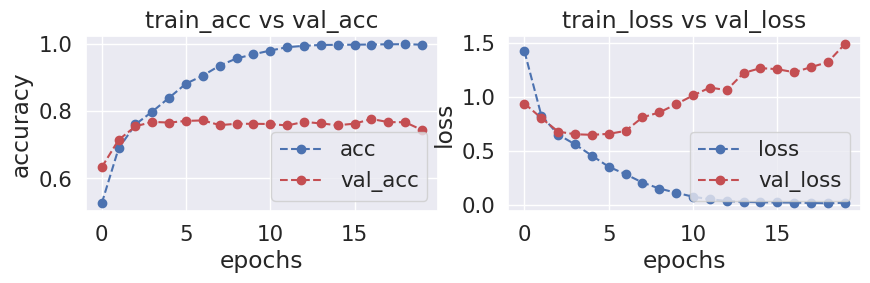

In [19]:
plot_accuracy_loss(history)

In [20]:
test_loss = model.evaluate(test_images, test_labels)

94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7383 - loss: 1.5525


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


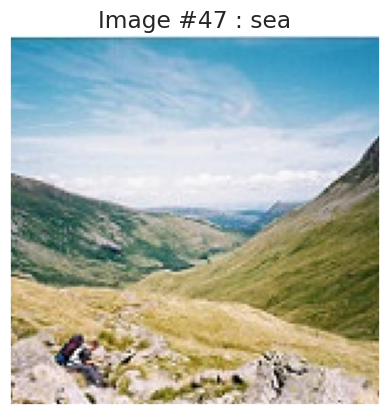

In [21]:
predictions = model.predict(test_images)     # Vector of probabilities
pred_labels = np.argmax(predictions, axis = 1) # We take the highest probability

display_random_image(class_names, test_images, pred_labels)

### Phân tích lỗi (Error Analysis)

Chúng ta có thể phân tích các lỗi của mô hình để hiểu rõ hơn **những loại hình ảnh nào khiến bộ phân loại gặp khó khăn**.

Việc phân tích này giúp xác định các điểm yếu của mô hình, chẳng hạn như:

- Các lớp ảnh dễ bị nhầm lẫn với nhau.
- Những đặc điểm hình ảnh mà mô hình chưa học tốt.
- Các trường hợp dữ liệu khó hoặc có chất lượng thấp.

Từ đó, chúng ta có thể đưa ra các hướng cải thiện mô hình như điều chỉnh kiến trúc mạng, tăng cường dữ liệu (**data augmentation**) hoặc sử dụng các mô hình mạnh hơn.


In [22]:
def print_mislabeled_images(class_names, test_images, test_labels, pred_labels):
    """
        Print 25 examples of mislabeled images by the classifier, e.g when test_labels != pred_labels
    """
    BOO = (test_labels == pred_labels)
    mislabeled_indices = np.where(BOO == 0)
    mislabeled_images = test_images[mislabeled_indices]
    mislabeled_labels = pred_labels[mislabeled_indices]

    title = "Some examples of mislabeled images by the classifier:"
    display_examples(class_names,  mislabeled_images, mislabeled_labels)

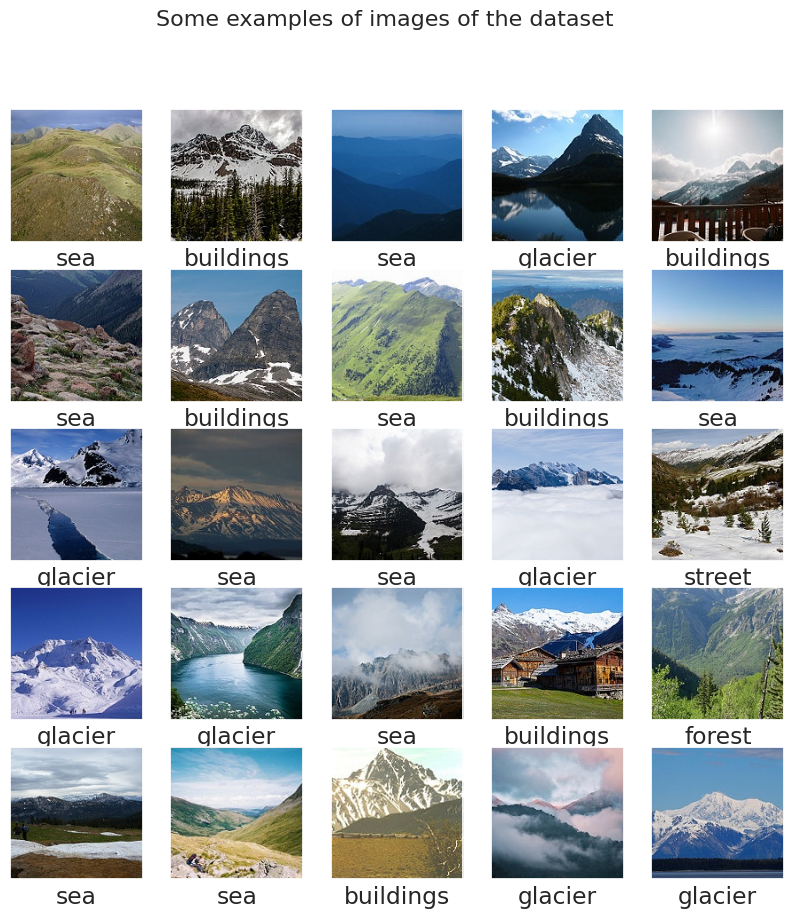

In [23]:
print_mislabeled_images(class_names, test_images, test_labels, pred_labels)

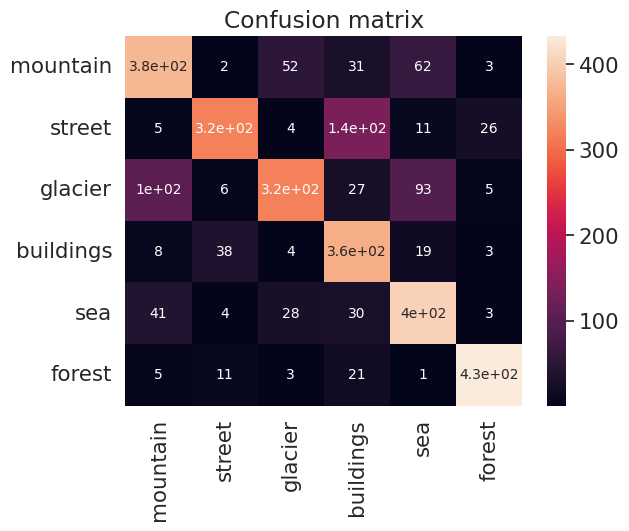

In [24]:
CM = confusion_matrix(test_labels, pred_labels)
ax = plt.axes()
sn.heatmap(CM, annot=True, 
           annot_kws={"size": 10}, 
           xticklabels=class_names, 
           yticklabels=class_names, ax = ax)
ax.set_title('Confusion matrix')
plt.show()

### Kết luận: Bộ phân loại gặp khó khăn với một số loại hình ảnh

Qua quá trình phân tích lỗi, có thể thấy rằng bộ phân loại gặp khó khăn chủ yếu với hai nhóm hình ảnh:

- **Street và Building:**  
  Mô hình thường nhầm lẫn giữa hai lớp này. Điều này có thể hiểu được vì trong các bức ảnh đường phố thường xuất hiện nhiều tòa nhà, khiến việc phân biệt trở nên khó khăn.

- **Sea, Glacier và Mountain:**  
  Mô hình cũng gặp khó khăn trong việc phân biệt các lớp này. Đối với con người, việc phân loại hoàn toàn chính xác giữa biển, sông băng và núi cũng không phải lúc nào cũng dễ dàng do chúng có thể có những đặc điểm hình ảnh tương đồng.

Tuy nhiên, mô hình có khả năng nhận diện **Forest** rất chính xác, cho thấy các đặc trưng của khu rừng được CNN học khá tốt.

### Cập nhật trung gian (Tháng 01/2020)

Các hướng cải thiện mô hình được thử nghiệm bao gồm:

- **Feature Extraction với VGG16 được huấn luyện trên ImageNet**  
  Sử dụng các đặc trưng đã được học từ mô hình VGG16 thay vì huấn luyện CNN hoàn toàn từ đầu.

- **Ensemble các mô hình Neural Network sử dụng đặc trưng được trích xuất từ VGG16**  
  Kết hợp nhiều mô hình mạng nơ-ron để cải thiện độ chính xác dự đoán.

  Tham khảo ý tưởng từ:
  https://machinelearningmastery.com/model-averaging-ensemble-for-deep-learning-neural-networks/

- **Fine-tuning với VGG16 được huấn luyện trên ImageNet**  
  Điều chỉnh lại các trọng số của VGG16 trên bộ dữ liệu Intel Image Classification để mô hình thích nghi tốt hơn với bài toán cụ thể.


## Trích xuất đặc trưng với VGG16 được huấn luyện trên ImageNet

Chúng ta có thể sử dụng mô hình **VGG16** đã được huấn luyện trước trên bộ dữ liệu **ImageNet** để thực hiện quá trình **trích xuất đặc trưng (feature extraction)** từ hình ảnh.

Thay vì huấn luyện một mạng CNN hoàn toàn từ đầu, chúng ta tận dụng các đặc trưng mà VGG16 đã học được từ hàng triệu hình ảnh, sau đó sử dụng các đặc trưng này cho bài toán phân loại ảnh trên bộ dữ liệu Intel Image Classification.


In [25]:
from keras.applications.vgg16 import VGG16
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input

model = VGG16(weights='imagenet', include_top=False)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [26]:
train_features = model.predict(train_images)
test_features = model.predict(test_images)

439/439 ━━━━━━━━━━━━━━━━━━━━ 67s 131ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 183ms/step


### Trực quan hóa các đặc trưng thông qua PCA

Chúng ta có thể trực quan hóa các đặc trưng bằng phương pháp PCA (Principal Component Analysis).


In [27]:
n_train, x, y, z = train_features.shape
n_test, x, y, z = test_features.shape
numFeatures = x * y * z

In [28]:
from sklearn import decomposition

pca = decomposition.PCA(n_components = 2)

X = train_features.reshape((n_train, x*y*z))
pca.fit(X)

C = pca.transform(X) # Représentation des individus dans les nouveaux axe
C1 = C[:,0]
C2 = C[:,1]

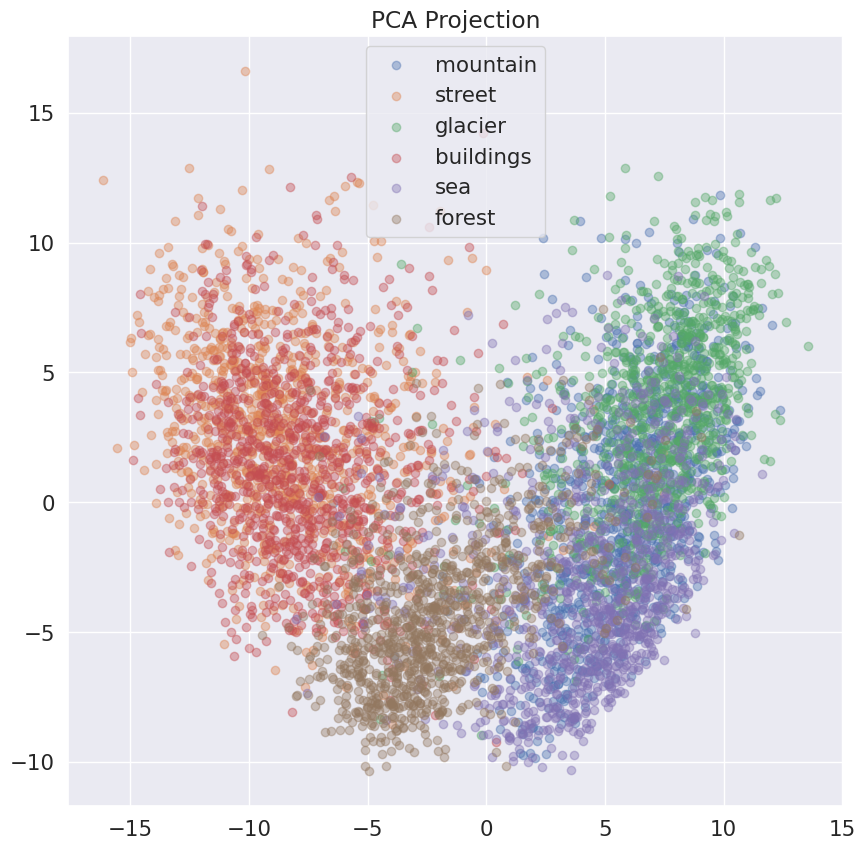

In [29]:
### Figures

plt.subplots(figsize=(10,10))

for i, class_name in enumerate(class_names):
    plt.scatter(C1[train_labels == i][:1000], C2[train_labels == i][:1000], label = class_name, alpha=0.4)
plt.legend()
plt.title("PCA Projection")
plt.show()

Nhờ PCA, chúng ta có thể xác định được các cụm (clusters) trong dữ liệu. Các cụm này tương ứng tương đối với các nhãn (labels).

Chúng ta có thể thấy rằng các điểm dữ liệu của **glacier** và **mountain** nằm rất gần nhau, bởi vì VGG xem chúng là những hình ảnh có đặc điểm rất tương đồng.

Ngoài ra, chúng ta nhận thấy rằng không có sự phân biệt rõ ràng giữa **building** và **street**.


### Huấn luyện trên đầu ra của VGG

Chúng ta sẽ huấn luyện một mạng nơ-ron đơn giản với một lớp (one-layer Neural Network) trên các đặc trưng đã được trích xuất từ VGG.


In [30]:
model2 = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (x, y, z)),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(6, activation=tf.nn.softmax)
])

model2.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

history2 = model2.fit(train_features, train_labels, batch_size=128, epochs=15, validation_split = 0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8064 - loss: 0.5255 - val_accuracy: 0.8504 - val_loss: 0.4002
Epoch 2/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8928 - loss: 0.3029 - val_accuracy: 0.8764 - val_loss: 0.3492
Epoch 3/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9106 - loss: 0.2493 - val_accuracy: 0.8707 - val_loss: 0.3595
Epoch 4/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9327 - loss: 0.1981 - val_accuracy: 0.8728 - val_loss: 0.3481
Epoch 5/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9433 - loss: 0.1693 - val_accuracy: 0.8767 - val_loss: 0.3470
Epoch 6/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9538 - loss: 0.1404 - val_accuracy: 0.8710 - val_loss: 0.3700
Epoch 7/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9604 - loss: 0.1220 - val_accuracy: 0.8693 - val_loss: 0.3865
Epoch 8/15
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9676 - loss: 0.1059 - val_accuracy: 0.8703 - val_loss

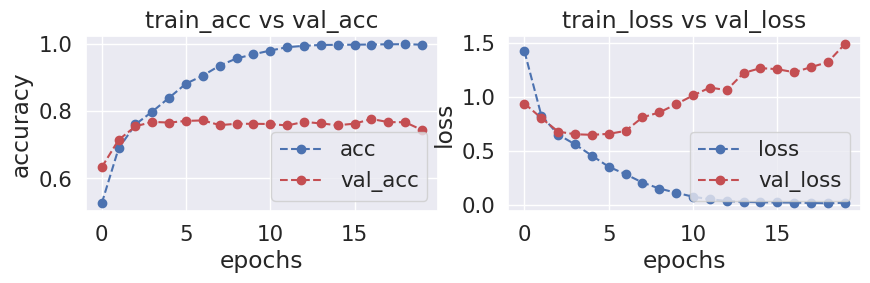

In [31]:
plot_accuracy_loss(history)

In [32]:
test_loss = model2.evaluate(test_features, test_labels)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8730 - loss: 0.4171


## Ensemble Neural Networks


In [33]:
np.random.seed(seed=1997)
# Number of estimators
n_estimators = 10
# Proporition of samples to use to train each training
max_samples = 0.8

max_samples *= n_train
max_samples = int(max_samples)

In [34]:
models = list()

random = np.random.randint(50, 100, size=n_estimators)

for i in range(n_estimators):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(x, y, z)),
        tf.keras.layers.Flatten(),

        tf.keras.layers.Dense(int(random[i]), activation='relu'),

        tf.keras.layers.Dense(6, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    models.append(model)

In [35]:
histories = []

for i in range(n_estimators):
    # Train each model on a bag of the training data
    train_idx = np.random.choice(len(train_features), size = max_samples)
    histories.append(models[i].fit(train_features[train_idx], train_labels[train_idx], batch_size=128, epochs=10, validation_split = 0.1))

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.8169 - loss: 0.4914 - val_accuracy: 0.8869 - val_loss: 0.3243
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9165 - loss: 0.2508 - val_accuracy: 0.9065 - val_loss: 0.2645
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9428 - loss: 0.1779 - val_accuracy: 0.8931 - val_loss: 0.3061
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9624 - loss: 0.1291 - val_accuracy: 0.9225 - val_loss: 0.2428
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9729 - loss: 0.0994 - val_accuracy: 0.9199 - val_loss: 0.2361
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9843 - loss: 0.0721 - val_accuracy: 0.9243 - val_loss: 0.2284
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9857 - loss: 0.0599 - val_accuracy: 0.9314 - val_loss: 0.2271
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9905 - loss: 0.0461 - val_accuracy: 0.9332 - val_loss

In [36]:
predictions = []
for i in range(n_estimators):
    predictions.append(models[i].predict(test_features))
    
predictions = np.array(predictions)
predictions = predictions.sum(axis = 0)
pred_labels = predictions.argmax(axis=1)

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [37]:
from sklearn.metrics import accuracy_score
print("Accuracy : {}".format(accuracy_score(test_labels, pred_labels)))

Accuracy : 0.8856666666666667


## Fine Tuning VGG ImageNet


In [38]:
from keras.models import Model

model = VGG16(weights='imagenet', include_top=False)
model = Model(inputs=model.inputs, outputs=model.layers[-5].output)

In [39]:
train_features = model.predict(train_images)
test_features = model.predict(test_images)

439/439 ━━━━━━━━━━━━━━━━━━━━ 50s 113ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step


In [40]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model


model2 = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(150,150,3)
)

# lấy output của layer thứ -5
feature_extractor = Model(
    inputs=model2.input,
    outputs=model2.layers[-5].output
)

feature_extractor.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_14 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 37, 37, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 18, 18, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 18, 18, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 9, 9, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,635,264 (29.13 MB)

 Trainable params: 7,635,264 (29.13 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
from tensorflow.keras.layers import Input

feature_input = Input(shape=(9, 9, 512))

x = Conv2D(64, (3,3), activation='relu')(feature_input)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
x = Dense(100, activation='relu')(x)
x = Dense(6, activation='softmax')(x)

new_model = Model(inputs=feature_input, outputs=x)

In [47]:
new_model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

In [48]:
new_model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 9, 9, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 64)       │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 100)            │        57,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353,282 (1.35 MB)

 Trainable params: 353,282 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
history = new_model.fit(
    train_features,
    train_labels,
    batch_size=128,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.7446 - loss: 0.7925 - val_accuracy: 0.8611 - val_loss: 0.3868
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8995 - loss: 0.2837 - val_accuracy: 0.8750 - val_loss: 0.3498
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9373 - loss: 0.1860 - val_accuracy: 0.8696 - val_loss: 0.3566
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9657 - loss: 0.1104 - val_accuracy: 0.8821 - val_loss: 0.3567
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9769 - loss: 0.0737 - val_accuracy: 0.8725 - val_loss: 0.4115
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9906 - loss: 0.0407 - val_accuracy: 0.8764 - val_loss: 0.4216
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9964 - loss: 0.0212 - val_accuracy: 0.8867 - val_loss: 0.4459
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9988 - loss: 0.0146 - val_accuracy: 0.8874 - v

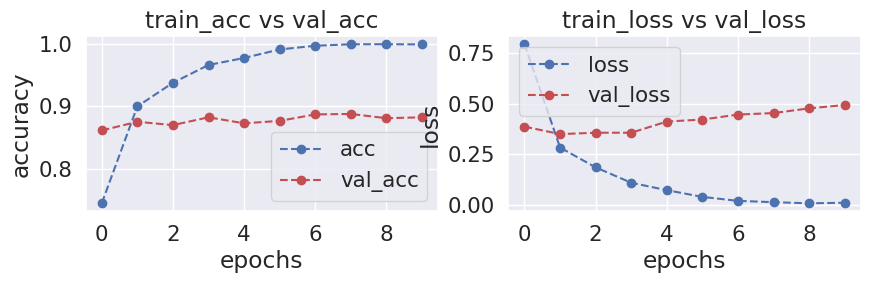

In [50]:
plot_accuracy_loss(history)

In [51]:
from sklearn.metrics import accuracy_score

predictions = new_model.predict(test_features)    
pred_labels = np.argmax(predictions, axis = 1)
print("Accuracy : {}".format(accuracy_score(test_labels, pred_labels)))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
Accuracy : 0.8806666666666667
